# Latent Network Viewer

This notebook loads a trained latent network from `data/latent_network/latent_network.pt`, then plots:

1. prediction vs. target neural activity for one dataset/session/condition
2. latent unit activity and recurrent weights `W`

The final cells expose `W` and the unit slices so you can experiment with recurrent weights interactively.

In [34]:
%matplotlib inline

import copy
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import _8_LatentNetwork as ln
importlib.reload(ln)

checkpoint_path = Path(ln.SAVE_LATENT_PATH) / 'latent_network.pt'
print('checkpoint:', checkpoint_path)
print('exists:', checkpoint_path.exists())

checkpoint: data/latent_network/latent_network.pt
exists: True


## Load The Trained Model

`results` contains the trained RNN, trained session readouts, training metadata, and loss history.

In [13]:
results = ln.load_latent_network(checkpoint_path=str(checkpoint_path))

rnn = results['rnn']
datasets = results['datasets']

print('loaded datasets:', len(datasets))
print('RNN units:', rnn.n_units)
print('time bins:', rnn.n_time)
print('loss history length:', len(results['loss_history']))

loaded datasets: 5
RNN units: 120
time bins: 24
loss history length: 3000


## Choose An Example

Change these values to inspect a different target dataset, session, or condition.

In [14]:
dataset_idx = 0   # which cells/activity file to use
fx = 0            # session index, 0..32
condition = 'P1'  # one of ln.CONDITIONS, currently ['P1', 'A1']

print('conditions:', ln.CONDITIONS)

conditions: ['P1', 'A1']


## Plot Prediction Vs. Target

This calls the same plotting helper used by `_8_LatentNetwork.py`. Rows are top neurons and columns are time bins.

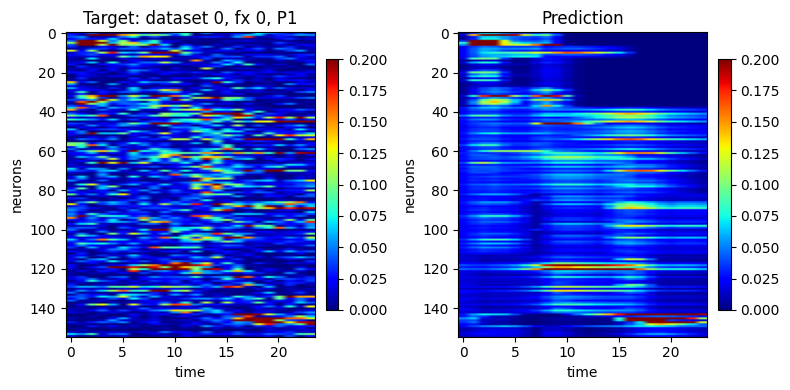

In [15]:
ln.plot_prediction_vs_target(
    results,
    dataset_idx=dataset_idx,
    fx=fx,
    condition=condition,
)
plt.show()

## Plot Latent Unit Activity And Recurrent Weights

The units are ordered as `S`, `D`, `R`, and within each population as `Group0`, `Group1`, `Group2`, `Group3`.

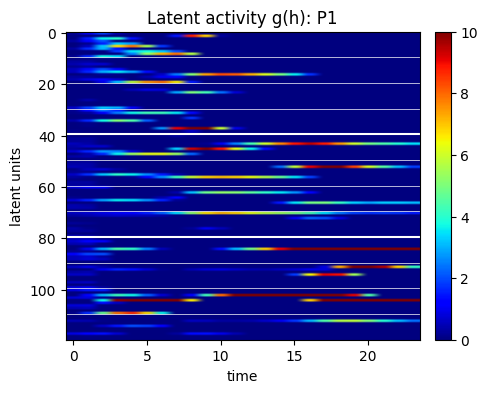

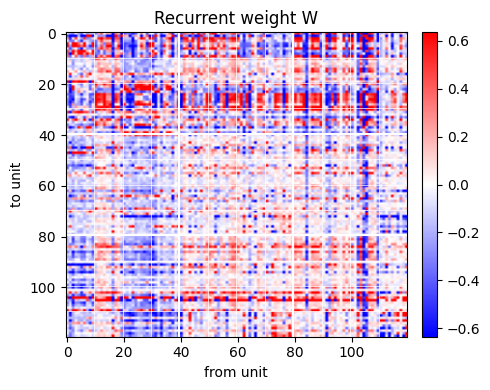

In [35]:
ln.plot_latent_activity_and_weights(
    results,
    condition=condition,
)
plt.show()

## Inspect The Recurrent Weight Matrix

`W[to_unit, from_unit]` is used in the RNN update through `g(h) @ W.T`.

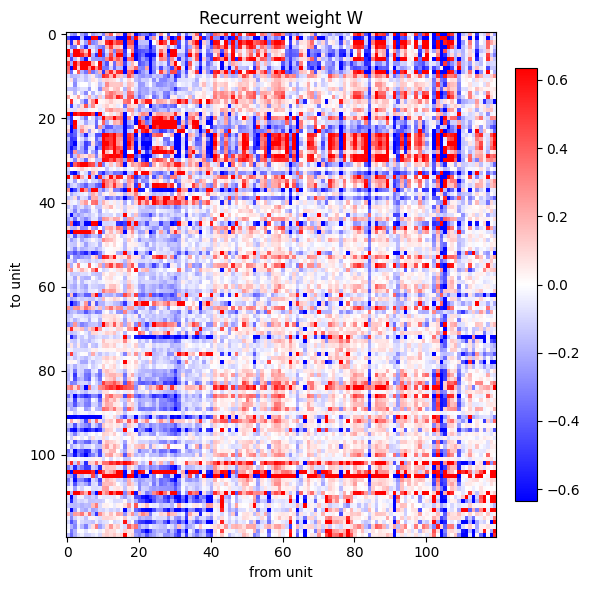

In [33]:
W = rnn.W.detach().cpu().numpy()

plt.figure(figsize=(6,6))
wlim = np.max(np.abs(W)) / 4
if wlim == 0:
    wlim = 1
plt.imshow(W, cmap='bwr', vmin=-wlim, vmax=wlim, aspect='auto')
plt.title('Recurrent weight W')
plt.xlabel('from unit')
plt.ylabel('to unit')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()

W shape: (120, 120)
W min / mean / max: -2.3506887 -0.008161081 2.5419056

Unit slices:
('S', 'Group0'): 0:10
('S', 'Group1'): 10:20
('S', 'Group2'): 20:30
('S', 'Group3'): 30:40
('D', 'Group0'): 40:50
('D', 'Group1'): 50:60
('D', 'Group2'): 60:70
('D', 'Group3'): 70:80
('R', 'Group0'): 80:90
('R', 'Group1'): 90:100
('R', 'Group2'): 100:110
('R', 'Group3'): 110:120
wstart: 40
wstop: 80


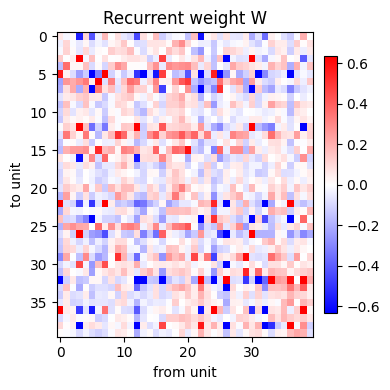

In [ ]:
W = rnn.W.detach().cpu().numpy()

print('W shape:', W.shape)
print('W min / mean / max:', W.min(), W.mean(), W.max())
print('\nUnit slices:')
for key, sl in ln.UNIT_SLICES.items():
    print(f'{key}: {sl.start}:{sl.stop}')
    if key == ('D','Group0'):
        wstart = sl.start
    if key == ('D','Group3'):
        wstop = sl.stop
print(f'wstart: {wstart}')
print(f'wstop: {wstop}')

Wtrim = W[wstart:wstop,wstart:wstop]
plt.figure(figsize=(4,4))
wlim = np.max(np.abs(W)) / 4
if wlim == 0:
    wlim = 1
plt.imshow(Wtrim, cmap='bwr', vmin=-wlim, vmax=wlim, aspect='auto')
plt.title('Recurrent weight W')
plt.xlabel('from unit')
plt.ylabel('to unit')
plt.colorbar(fraction=0.046, pad=0.04)
# plt.xlim([40,80])
# plt.ylim([40,80])
plt.tight_layout()

In [32]:
print('group1', np.mean(Wtrim[0:20,0:20]))
print('group2', np.mean(Wtrim[20:40,0:20]))
print('group3', np.mean(Wtrim[0:20,20:40]))
print('group4', np.mean(Wtrim[20:40,20:40]))

group1 0.045741547
group2 -0.016950635
group3 -0.017833648
group4 0.02711418


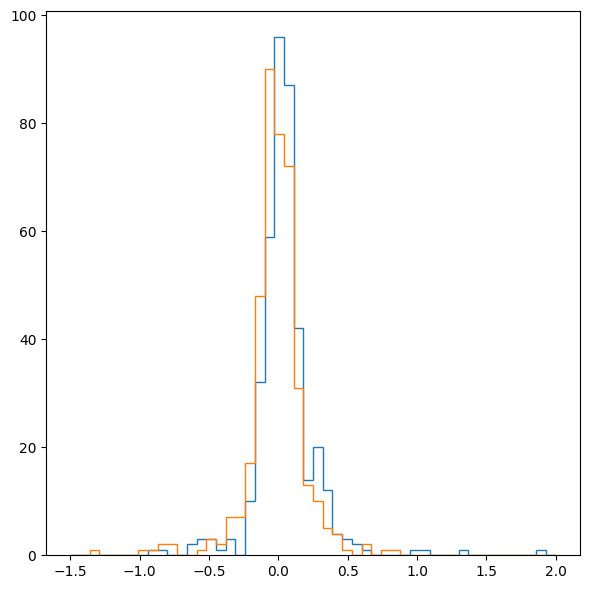

In [30]:
plt.figure(figsize=(6,6))
plt.hist(Wtrim[0:20,0:20].ravel(),bins=50,histtype='step', range=(-1.5,2))
plt.hist(Wtrim[20:40,0:20].ravel(),bins=50,histtype='step', range=(-1.5,2))
# plt.hist(Wtrim[0:20,20:40].ravel(),bins=50,histtype='step', range=(-1.5,2))
# plt.hist(Wtrim[20:40,20:40].ravel(),bins=50,histtype='step', range=(-1.5,2))
plt.tight_layout()

## Play With A Copy Of `W`

This cell shows one safe pattern: copy the trained RNN, modify recurrent weights in the copy, then simulate the modified model. The saved checkpoint is unchanged.

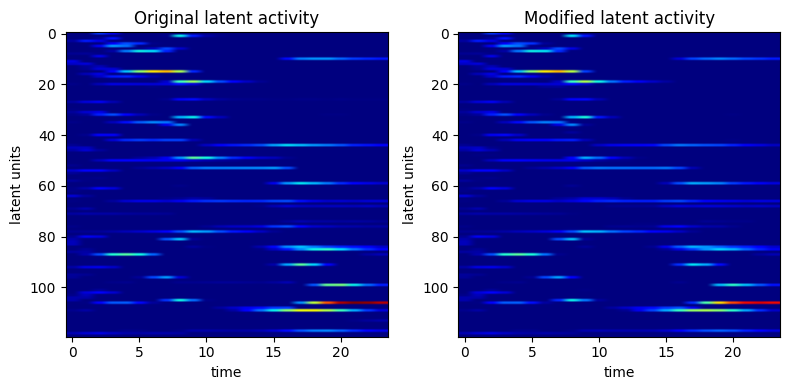

In [7]:
rnn_modified = copy.deepcopy(rnn)

# Example manipulation: remove connections from S Group0 units to D Group0 units.
src = ln.UNIT_SLICES[('S', 'Group0')]
dst = ln.UNIT_SLICES[('D', 'Group0')]

with torch.no_grad():
    rnn_modified.W[dst, src] = 0.0

with torch.no_grad():
    g_original = rnn()[condition].T.cpu().numpy()
    g_modified = rnn_modified()[condition].T.cpu().numpy()

vmax = max(np.max(g_original), np.max(g_modified))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(g_original, aspect='auto', cmap='jet', vmin=0, vmax=vmax)
plt.title('Original latent activity')
plt.xlabel('time')
plt.ylabel('latent units')

plt.subplot(1, 2, 2)
plt.imshow(g_modified, aspect='auto', cmap='jet', vmin=0, vmax=vmax)
plt.title('Modified latent activity')
plt.xlabel('time')
plt.ylabel('latent units')

plt.tight_layout()